![Curso Schwarz-Sosa-Suriano](http://www.fi.uba.ar/sites/default/files/logo.png)

# Ecuaciones no Lineales - Primera Parte

***

**Curso Schwarz - Sosa - Suriano**
- Métodos Numéricos. *Curso 2*
- Análisis Numérico I. *Curso 4*
- Métodos Matemáticos y Numéricos. *Curso 6*

### Búsqueda de raíces en ecuaciones no lineales
___

Problema a resolver: Hallar $p$ tal que $f(p)=0,$ $p  \in [a,b].$

¿Por qué necesitamos una solución numérica a este problema?
- No siempre podemos despejar la incóginta.
- Muchas veces resulta más cómodo plantear una solución numérica e iterativa.
- Otras veces no existe solución algebraica al problema que queremos resolver.

### Método de la bisección
___
Supongamos una función cualquiera $f(x)$ y hallemos el valor de $\hat{x}$, tal que $f(\hat{x}) = 0$, siendo $\hat{x} \in [a,b]$.

Calculemos nuestra primera aproximación de $\hat{x}$ tomando el valor medio del intervalo, es decir:

$$ x_1= \frac{a+b}{2} $$
1. Verificar si es la solución, es decir que $f(x_1) = 0$. 
2. Si no lo es, volver a definir el intervalo. Para ello, verifiquemos que $f(a) · f(x_1) < 0$. 
3. Si es cierto, entonces nuestro nuevo intervalo será $[a, x_1]$ y si no lo es, nuestro intervalo será $[x_1, b]$. 
4. Repetir el proceso y definir $x_2$ como el valor medio de mi nuevo intervalo.
5. ¿Hasta cuándo? Tengo que definir una tolerancia y un criterio de corte

### Criterio de corte y tolerancia
___

¿Hasta cuándo? Tengo que definir una tolerancia y un criterio de corte.

Algunos _criterios de corte_:
 
$$Error_{relativo}=\frac{|x_{n+1}-x_{n}|}{|x_{n+1}|} \leq Tolerancia $$

$$Error_{absoluto}=|x_{n+1}-x_{n}| \leq Tolerancia $$

$$Error_{absolutodeF}=|f(x_{n+1})|\leq Tolerancia$$

En general preferimos el *error relativo* por ser más representativo.

La _Tolerancia_ se elige en función a las características del problema que quiero resolver.








In [ ]:
import numpy as np #librería para operaciones algebraicas y numéricas
import pandas as pd #librería para manejo de datos

#programo el método bisección
def biseccion(a, b , tol, itmax = 100): 
        df = pd.DataFrame(columns=('ai','bi','pi','cond','f_ai_f_pi'))
        a = a 
        b = b
        contador = 0  
        x0, x1 = a, b 
        if(f(a) * f(b)>0):         #condicion de aplicabilidad del método
            print( "El método no resuelve este tipo de raíz")
            return
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            x0 = x1                                                 
            x1 = (a + b)/2                      
            f_ai_f_pi = f(a) * f(x1)
            if f_ai_f_pi < 0:      
                df.loc[contador] = [a,b,(a+b)/2,'<0',f_ai_f_pi]
                b = x1
            else:
                df.loc[contador] = [a,b,(a+b)/2,'>0',f_ai_f_pi]
                a = x1
            contador += 1                      
        error = abs((x1 - x0) / x1)
        print('El método de bisección convergió en',contador,'iteraciones')
        return df

### Ejemplo usando bisección
___

Hallar $p$ tal que $f(p)=0,$ $p  \in [0,4]$ siendo :
$$f(x)=(x+e^\frac{x}{2}).cos(x)+5$$


In [ ]:
#defino el intervalo de arranque y la tolerancia
A=-1.9
B=3.8
tolerancia=10**(-5)

def f(x):#definimos la función con la que vamos a trabajar
    return (x**3-3*x**2+3)   #Acá está el ejemplo de arriba, deben cambiar la función si quieren probar otra 

#A la hora de probar un ejemplo, recueden que para aplicar estos dos métodos se debe cumplir:
# - que la función sea contínua en el intervalo
# - que exista una raíz en el intervalo y que sea única y con multiplicidad impar (si 'rebota', no puedo aplicar el método)

ejemplo=biseccion(A, B, tolerancia)


El método de bisección convergió en 30 iteraciones


In [ ]:
from IPython.display import display, Math
import sympy.printing as printing

a = ejemplo.ai
b = ejemplo.bi
x = ejemplo.pi
cond= ejemplo.cond

print ("Analicemos las primeras iteraciones. \n")  

for p in range (5):
    print ("Iteración "+str(p)+": ")
    print ("Tenemos como información que: \n")
    ec = "a_"+str(p)+"= "+str(a[p])+";b_"+str(p)+"= "+str(b[p])+";x_"+str(p)+"=\\frac{a_"+str(p)+"+b_"+str(p)+"}{2}"+"="+str(x[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    
    print ("Evalúo en que intervalo se encuentra la raíz:")
        
    ec = "f(a_"+str(p)+")*f(x_"+str(p)+")"+"= "+"f("+str(a[p])+")*f("+str(x[p])+")"+str(cond[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    
    print ("Por lo tanto redefino los extremos del intervalo en la próxima iteración. \n") 
    
    
    
    

Analicemos las primeras iteraciones. 

Iteración 0: 
Tenemos como información que: 



<IPython.core.display.Math object>

Evalúo en que intervalo se encuentra la raíz:


<IPython.core.display.Math object>

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 

Iteración 1: 
Tenemos como información que: 



...

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 

Iteración 4: 
Tenemos como información que: 



<IPython.core.display.Math object>

Evalúo en que intervalo se encuentra la raíz:


<IPython.core.display.Math object>

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 



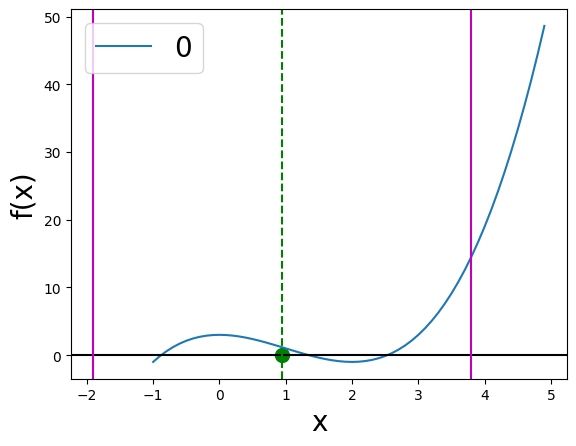

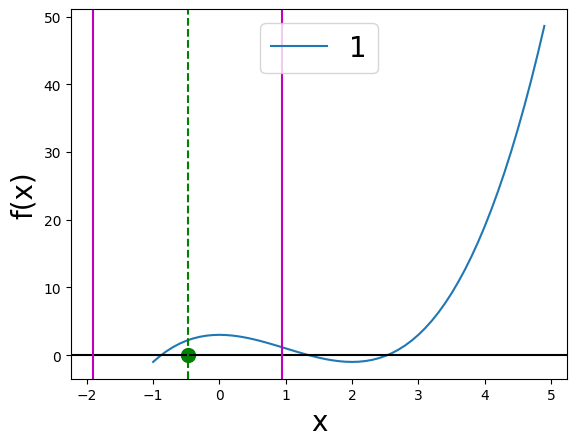

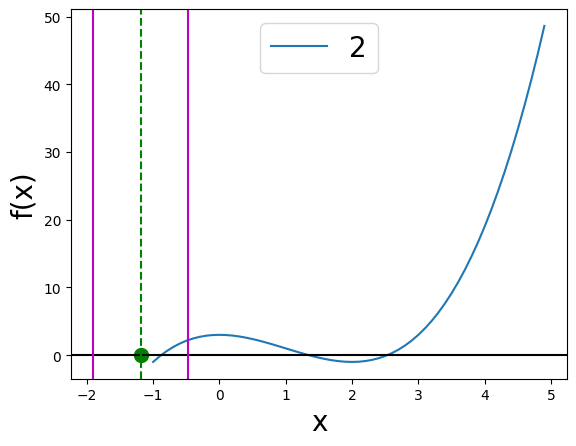

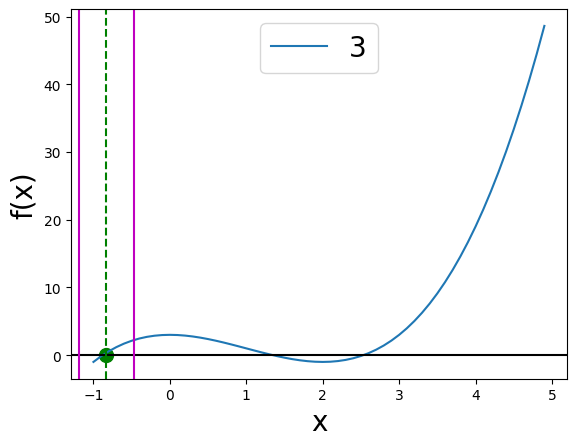

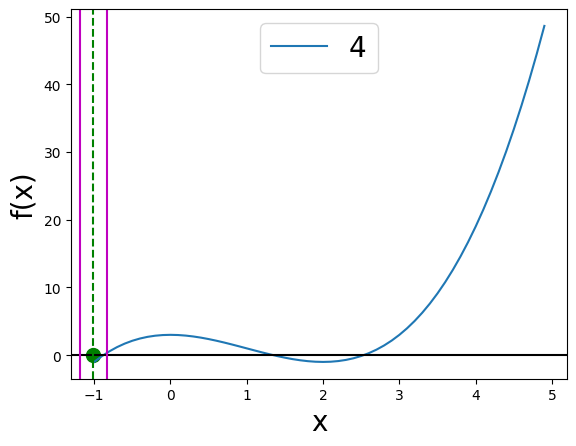

In [ ]:
import matplotlib.pyplot as plt
ejex = np.arange(-1, 5, 0.1);
y = f(ejex)

for p in range (5):
    fig = plt.figure()
    plt.plot(ejex, y)
    plt.xlabel('x',fontsize=20)
    plt.ylabel('f(x)',fontsize=20)
    plt.legend(str(p),fontsize=20)
    plt.axhline(y=0, color='k')   
    plt.scatter(x=x[p], y=0, marker="o", c='green', s=100)
    plt.axvline(x=x[p], color='g',linestyle='dashed') 
    plt.axvline(x=a[p], color='m') 
    plt.axvline(x=b[p], color='m'); 

In [62]:
print('Resumen de resultados para bisección:')
print('A continuación se muestran las primeras iteraciones:')
ejemplo.tail(10)

# en la tabla, 'cond' hace referencia al producto de f(ai)*f(xi),
# la condición que estamos evaluando para redefinir el nuevo intervalo donde vamos a buscar la raíz.

Resumen de resultados para bisección:
A continuación se muestran las primeras iteraciones:


,ai,bi,pi,cond
20,-0.879385,-0.879380,-0.879383,<0
21,-0.879385,-0.879383,-0.879384,<0
22,-0.879385,-0.879384,-0.879385,<0
23,-0.879385,-0.879385,-0.879385,<0
24,-0.879385,-0.879385,-0.879385,<0
25,-0.879385,-0.879385,-0.879385,<0
26,-0.879385,-0.879385,-0.879385,<0
27,-0.879385,-0.879385,-0.879385,>0
28,-0.879385,-0.879385,-0.879385,>0
29,-0.879385,-0.879385,-0.879385,>0


### Método Regula falsi
___
Supongamos una función cualquiera $f(x)$ y hallemos el valor de $\hat{x}$, tal que $f(\hat{x}) = 0$, siendo $\hat{x} \in [a,b]$.

Calculemos nuestra primera aproximación de $\hat{x}$ utilizando la cuerda que une los extremos de la función, es decir:

$$ x_1= a_1-f(a_1)*\frac{b_1-a_1}{f(b_1)-f(a_1)}, ó $$  $$ x_1= b_1-f(b_1)*\frac{b_1-a_1}{f(b_1)-f(a_1)} $$
1. Verificar si es la solución, es decir que $f(x_1) = 0$. 
2. Si no lo es, volver a definir el intervalo. Para ello, verifiquemos que $f(a) · f(x_1) < 0$. 
3. Si es cierto, entonces nuestro nuevo intervalo será $[a, x_1]$ y si no lo es, nuestro intervalo será $[x_1, b]$. 
4. Repetir el proceso y definir $x_2$ como el valor medio de mi nuevo intervalo.
5. ¿Hasta cuándo? Tengo que definir una tolerancia y un criterio de corte

In [ ]:
def regulafalsi(a, b , tol, itmax = 100): 
        df = pd.DataFrame(columns=('ai','bi','pi','cond','f_ai_f_pi'))
        a = a 
        b = b
        contador = 0  
        x0, x1 = a, b 
        if(f(a) * f(b)>0):         #condicion de aplicabilidad del método
            print( "El método no resuelve este tipo de raíz")
            return
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            x0 = x1                                                 
            x1 = a-(f(a)*(b-a)/(f(b)-f(a)))                    
            f_ai_f_pi = f(a) * f(x1)
            if f_ai_f_pi < 0:      
                df.loc[contador] = [a,b,a-(f(a)*(b-a)/(f(b)-f(a))) ,'<0',f_ai_f_pi]
                b = x1
            else:
                df.loc[contador] = [a,b,a-(f(a)*(b-a)/(f(b)-f(a))) ,'>0',f_ai_f_pi]
                a = x1
            contador += 1                      
        error = abs((x1 - x0) / x1)
        print('El método de regula-falsi convergió en',contador,'iteraciones')
        return df

In [57]:
#aplico el método Regula Falsi al mismo ejemplo anterior

ejemploRF=regulafalsi(A, B, tolerancia)

El método de regula-falsi convergió en 31 iteraciones


In [58]:
aRF = ejemploRF.ai
bRF = ejemploRF.bi
xRF = ejemploRF.pi
condRF= ejemploRF.cond

print ("Analicemos las primeras iteraciones. \n")  

for p in range (5):
    print ("Iteración "+str(p)+": ")
    print ("Tenemos como información que: \n")
    ec = "a_"+str(p)+"= "+str(aRF[p])+";b_"+str(p)+"= "+str(bRF[p])+";x_"+str(p)+"=a_"+str(p)+"-f(a_"+str(p)+")*\\frac{b_"+str(p)+"-a_"+str(p)+"}{f(b_"+str(p)+")-f(a_"+str(p)+")}"+"="+str(xRF[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    
    print ("Evalúo en que intervalo se encuentra la raíz:")
        
    ec = "f(a_"+str(p)+")*f(x_"+str(p)+")"+"= "+"f("+str(aRF[p])+")*f("+str(xRF[p])+")"+str(condRF[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    
    print ("Por lo tanto redefino los extremos del intervalo en la próxima iteración. \n") 
    


Analicemos las primeras iteraciones. 

Iteración 0: 
Tenemos como información que: 



<IPython.core.display.Math object>

Evalúo en que intervalo se encuentra la raíz:


<IPython.core.display.Math object>

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 

Iteración 1: 
Tenemos como información que: 



...

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 

Iteración 4: 
Tenemos como información que: 



<IPython.core.display.Math object>

Evalúo en que intervalo se encuentra la raíz:


<IPython.core.display.Math object>

Por lo tanto redefino los extremos del intervalo en la próxima iteración. 



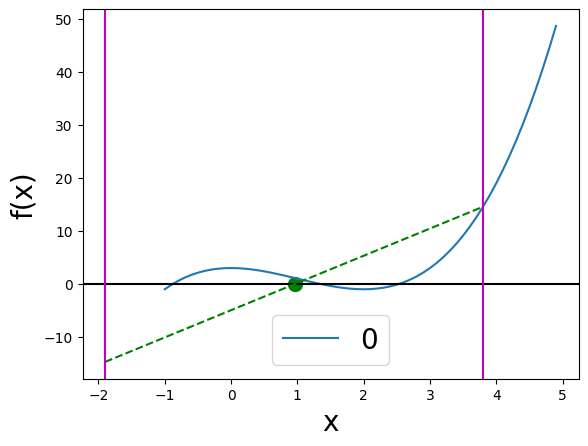

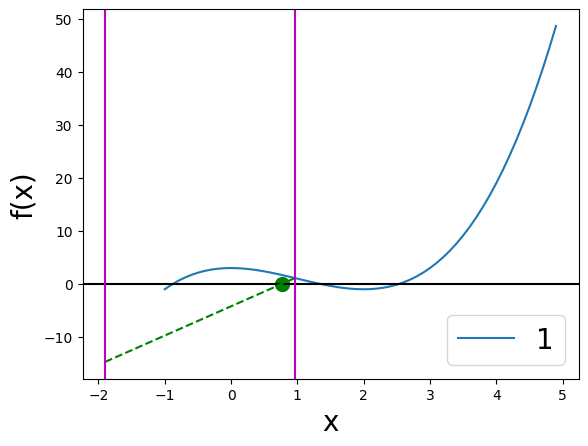

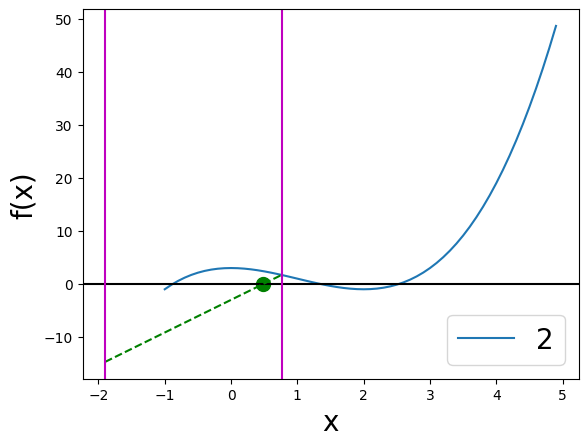

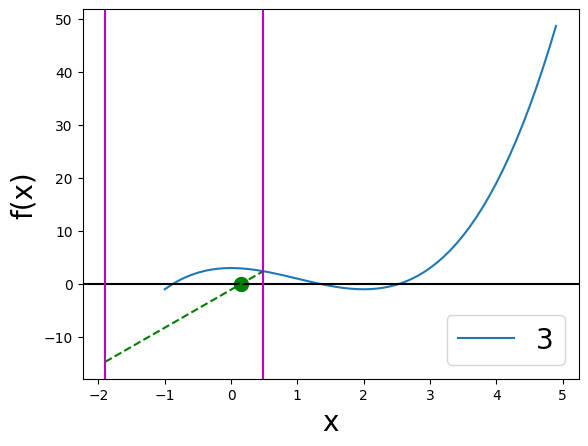

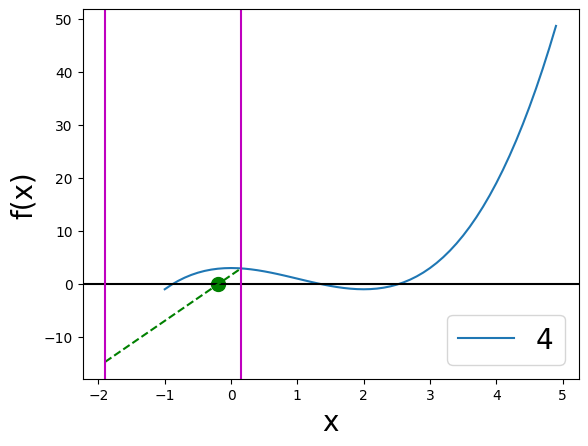

In [59]:
ejex = np.arange(-1, 5, 0.1);
y = f(ejex)

for p in range (5):
    fig = plt.figure()
    plt.plot(ejex, y)
    plt.xlabel('x',fontsize=20)
    plt.ylabel('f(x)',fontsize=20)
    plt.legend(str(p),fontsize=20)
    plt.axhline(y=0, color='k')   
    plt.scatter(x=xRF[p], y=0, marker="o", c='green', s=100)
    plt.plot([aRF[p],bRF[p]], [f(aRF[p]),f(bRF[p])], color='g',linestyle='dashed')
    plt.axvline(x=aRF[p], color='m') 
    plt.axvline(x=bRF[p], color='m'); 
    

In [ ]:
print('Resumen de resultados para Regula-Falsi:')
print('A continuación se muestran las primeras iteraciones:')
ejemploRF.head(10)

In [ ]:
# Calcular errores para el método Regula-Falsi
errores_rf = []
for i in range(len(ejemploRF)):
    if i == 0:
        # Para la primera iteración, no hay error relativo (no hay valor anterior)
        errores_rf.append(np.nan)
    else:
        # Error relativo entre iteraciones consecutivas
        error_relativo = abs(ejemploRF.pi[i] - ejemploRF.pi[i-1]) / abs(ejemploRF.pi[i])
        errores_rf.append(error_relativo)

# Agregar columna de errores al dataframe
ejemploRF_con_errores = ejemploRF.copy()
ejemploRF_con_errores['error_relativo'] = errores_rf

print("Dataframe con errores:")
print(ejemploRF_con_errores.head(10))

Resumen de resultados para Regula-Falsi:
A continuación se muestran las primeras iteraciones:


,ai,bi,pi,cond
0,-1.9,3.800000,0.963353,<0
1,-1.9,0.963353,0.762199,<0
2,-1.9,0.762199,0.486060,<0
3,-1.9,0.486060,0.150231,<0
4,-1.9,0.150231,-0.191269,<0
5,-1.9,-0.191269,-0.471637,<0
6,-1.9,-0.471637,-0.659738,<0
7,-1.9,-0.659738,-0.768159,<0
8,-1.9,-0.768159,-0.824989,<0
9,-1.9,-0.824989,-0.853257,<0


# Graficar los valores de p_i del método Regula-Falsi
plt.figure(figsize=(10, 6))
plt.plot(range(len(ejemploRF.pi)), ejemploRF.pi, 'ro-', label='p_i')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('p_i', fontsize=12)
plt.title('Evolución de p_i - Método Regula-Falsi', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Mostrar estadísticas de p_i
print(f"Valor inicial p_0: {ejemploRF.pi.iloc[0]:.6f}")
print(f"Valor final p_{len(ejemploRF.pi)-1}: {ejemploRF.pi.iloc[-1]:.6f}")
print(f"Raíz aproximada: {ejemploRF.pi.iloc[-1]:.6f}")
print(f"f(p_final): {f(ejemploRF.pi.iloc[-1]):.10e}")

# Graficar los errores del método Regula-Falsi
plt.figure(figsize=(10, 6))
plt.plot(range(len(errores_rf)), errores_rf, 'bo-', label='Error Relativo')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Error Relativo', fontsize=12)
plt.title('Evolución del Error Relativo - Método Regula-Falsi', fontsize=14)
plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Mostrar estadísticas del error
print(f"Error relativo inicial: {errores_rf[1]:.6e}")
print(f"Error relativo final: {errores_rf[-1]:.6e}")
print(f"Tasa de convergencia promedio: {np.mean([errores_rf[i+1]/errores_rf[i] for i in range(1, len(errores_rf)-1) if errores_rf[i] != 0 and not np.isnan(errores_rf[i+1]) and not np.isnan(errores_rf[i])]):.4f}")